In [15]:
# Import Library
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

In [16]:
df = pd.read_csv('../dataset/dataset_featured.csv')
df.head()

,tanggal,Harga,Cabai_lag_1,Cabai_lag_7,RR_lag_45,RH_lag_30,RR_rolling_mean_14,Bulan
0,2024-06-15,71650.0,71650.0,65550.0,2.5,70.0,6.950000,6
1,2024-06-16,71650.0,71650.0,64450.0,5.0,76.0,6.414286,6
2,2024-06-17,71650.0,71650.0,63350.0,3.9,75.0,5.660714,6
3,2024-06-18,71650.0,71650.0,65000.0,2.8,66.0,3.160714,6
4,2024-06-19,77500.0,71650.0,65000.0,1.7,70.0,1.494048,6


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tanggal             682 non-null    object 
 1   Harga               682 non-null    float64
 2   Cabai_lag_1         682 non-null    float64
 3   Cabai_lag_7         682 non-null    float64
 4   RR_lag_45           682 non-null    float64
 5   RH_lag_30           682 non-null    float64
 6   RR_rolling_mean_14  682 non-null    float64
 7   Bulan               682 non-null    int64  
dtypes: float64(6), int64(1), object(1)
memory usage: 42.8+ KB


In [18]:
df.describe()

,Harga,Cabai_lag_1,Cabai_lag_7,RR_lag_45,RH_lag_30,RR_rolling_mean_14,Bulan
count,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000
mean,56607.478006,56617.815249,56625.733138,6.248167,77.986804,6.369194,6.617302
std,11938.106425,11948.085475,11952.813751,11.075280,7.136685,4.662718,3.548927
min,36650.000000,36650.000000,36650.000000,0.000000,49.000000,0.000000,1.000000
25%,46966.666667,46966.666667,46966.666667,0.000000,73.000000,2.904464,3.000000
50%,53500.000000,53500.000000,53500.000000,1.000000,78.000000,5.162500,7.000000
75%,65475.000000,65500.000000,65537.500000,7.537500,83.000000,9.321429,10.000000
max,92150.000000,92150.000000,92150.000000,104.400000,96.000000,22.985714,12.000000


In [19]:
# cek missing value
print(df.isnull().sum())

# cek data duplikat
print(df.duplicated().sum())

tanggal               0
Harga                 0
Cabai_lag_1           0
Cabai_lag_7           0
RR_lag_45             0
RH_lag_30             0
RR_rolling_mean_14    0
Bulan                 0
dtype: int64
0


In [20]:
# ubah kolom date jika masih object
if 'tanggal' in df.columns:
    df['tanggal'] = pd.to_datetime(df['tanggal'])
    df = df.sort_values('tanggal')
    df = df.set_index('tanggal')

# indeks berbentuk datetime
df.index = pd.to_datetime(df.index)

# urutkan index
df = df.sort_index()

# set frequency business day
df = df.asfreq('B')

series = df['Harga']

print(series.head())
print(series.index.freq)

tanggal
2024-06-17    71650.0
2024-06-18    71650.0
2024-06-19    77500.0
2024-06-20    75850.0
2024-06-21    75850.0
Freq: B, Name: Harga, dtype: float64
<BusinessDay>


In [21]:
train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

print(f"Train size (80%): {len(train)}")
print(f"Test size (20%): {len(test)}")

Train size (80%): 388
Test size (20%): 98


In [22]:
# mencari parameter terbaik (p, d, q)
auto_model = auto_arima(
    train,
    seasonal=False,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=7115.399, Time=0.24 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=7122.502, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=7123.846, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=7123.977, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=7120.503, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=7114.009, Time=0.09 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=7115.825, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=7123.141, Time=0.06 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=7115.692, Time=0.15 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=7117.248, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=7113.527, Time=0.09 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=7115.167, Time=0.03 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=7115.397, Time=0.11 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=7115.723, Time=0.04 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept

In [23]:
order = auto_model.order

print("Best ARIMA order:", order)

model = ARIMA(train, order=order)
model_fit = model.fit()

print(model_fit.summary())


Best ARIMA order: (3, 1, 2)
                               SARIMAX Results                                
Dep. Variable:                  Harga   No. Observations:                  388
Model:                 ARIMA(3, 1, 2)   Log Likelihood               -3549.418
Date:                Sat, 30 May 2026   AIC                           7110.836
Time:                        22:55:18   BIC                           7134.587
Sample:                    06-17-2024   HQIC                          7120.254
                         - 12-10-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4791      0.184      2.608      0.009       0.119       0.839
ar.L2          0.5949      0.163      3.660      0.000       0.276       0.914
ar.L3         -0.1229   

In [24]:
prediction = model_fit.forecast(steps=len(test))
prediction.index = test.index
print(prediction.head())

tanggal
2025-12-11    71156.447750
2025-12-12    71029.583465
2025-12-15    70942.889274
2025-12-16    70831.226914
2025-12-17    70741.736535
Freq: B, Name: predicted_mean, dtype: float64


In [25]:

rmse = np.sqrt(mean_squared_error(test, prediction))
mape = mean_absolute_percentage_error(test, prediction) * 100
mean_price = series.mean()
rmse_percent = (rmse / mean_price) * 100


print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"Mean Price: {mean_price:.2f}")
print(f"RMSE (%): {rmse_percent:.2f}%")

RMSE: 17665.84
MAPE: 31.87%
Mean Price: 56535.70
RMSE (%): 31.25%


In [26]:
final_model = ARIMA(series, order=order)

final_model_fit = final_model.fit()
print(final_model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  Harga   No. Observations:                  486
Model:                 ARIMA(3, 1, 2)   Log Likelihood               -4442.953
Date:                Sat, 30 May 2026   AIC                           8897.907
Time:                        22:55:55   BIC                           8923.012
Sample:                    06-17-2024   HQIC                          8907.771
                         - 04-27-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3106      1.324     -0.235      0.815      -2.906       2.285
ar.L2          0.2758      0.586      0.471      0.638      -0.872       1.424
ar.L3         -0.0048      0.186     -0.026      0.9

c:\Users\jeebr\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\jeebr\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [27]:
forecast_30 = final_model_fit.forecast(steps=30)
print(forecast_30)

2026-04-28    64635.225396
2026-04-29    64629.868796
2026-04-30    64641.248491
2026-05-01    64636.066605
2026-05-04    64640.840695
2026-05-05    64637.873705
2026-05-06    64640.137039
2026-05-07    64638.592664
2026-05-08    64639.710932
2026-05-11    64638.926710
2026-05-12    64639.486180
2026-05-13    64639.090710
2026-05-14    64639.371639
2026-05-15    64639.172605
2026-05-18    64639.313819
2026-05-19    64639.213705
2026-05-20    64639.284710
2026-05-21    64639.234362
2026-05-22    64639.270067
2026-05-25    64639.244747
2026-05-26    64639.262703
2026-05-27    64639.249970
2026-05-28    64639.258999
2026-05-29    64639.252596
2026-06-01    64639.257137
2026-06-02    64639.253917
2026-06-03    64639.256201
2026-06-04    64639.254581
2026-06-05    64639.255730
2026-06-08    64639.254915
Freq: B, Name: predicted_mean, dtype: float64


In [28]:
# tanggal prediksi

future_dates = pd.date_range(
    start=series.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq='D'
)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast_Close': forecast_30.values
})

forecast_df

,Date,Forecast_Close
0,2026-04-28,64635.225396
1,2026-04-29,64629.868796
2,2026-04-30,64641.248491
3,2026-05-01,64636.066605
4,2026-05-02,64640.840695
5,2026-05-03,64637.873705
6,2026-05-04,64640.137039
7,2026-05-05,64638.592664
8,2026-05-06,64639.710932
9,2026-05-07,64638.926710


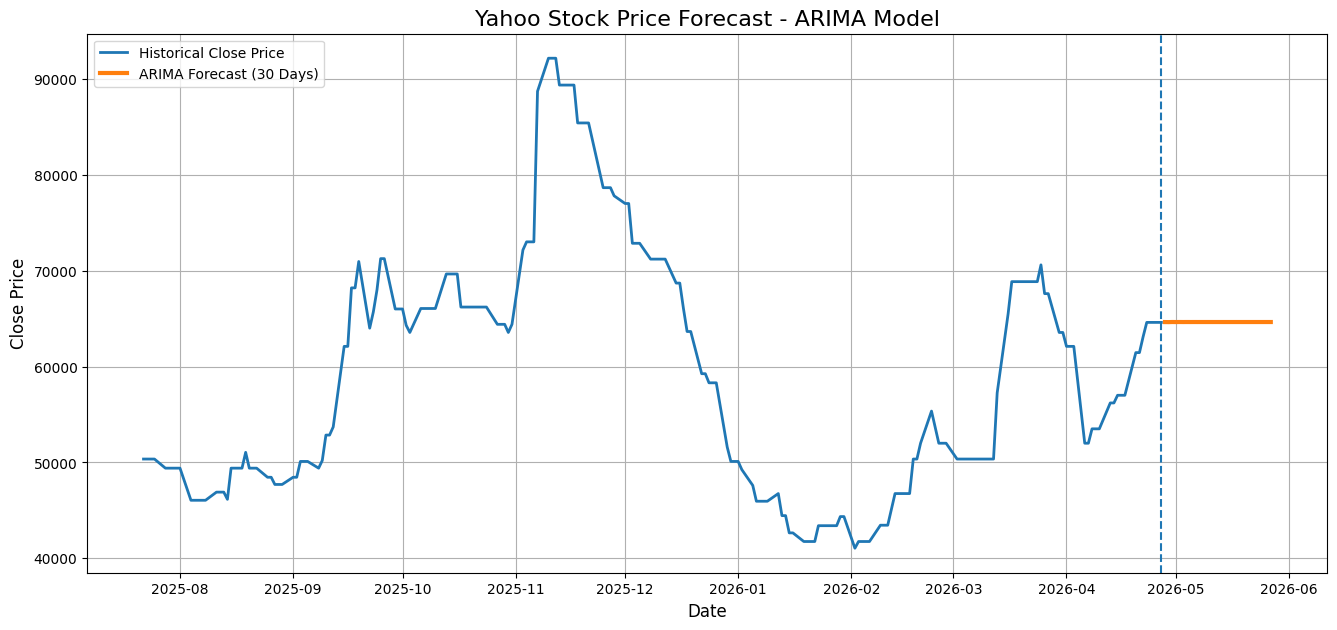

In [29]:
# Visualisasi prediksi untuk 30 hari

plt.figure(figsize=(16,7))

# data historis 200 hari terakhir
plt.plot(
    series.index[-200:],
    series[-200:],
    label='Historical Close Price',
    linewidth=2
)

# forecast 30 hari
plt.plot(
    forecast_df['Date'],
    forecast_df['Forecast_Close'],
    label='ARIMA Forecast (30 Days)',
    linewidth=3
)

# titik awal forecast
plt.axvline(
    x=series.index[-1],
    linestyle='--'
)
plt.title('Yahoo Stock Price Forecast - ARIMA Model', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

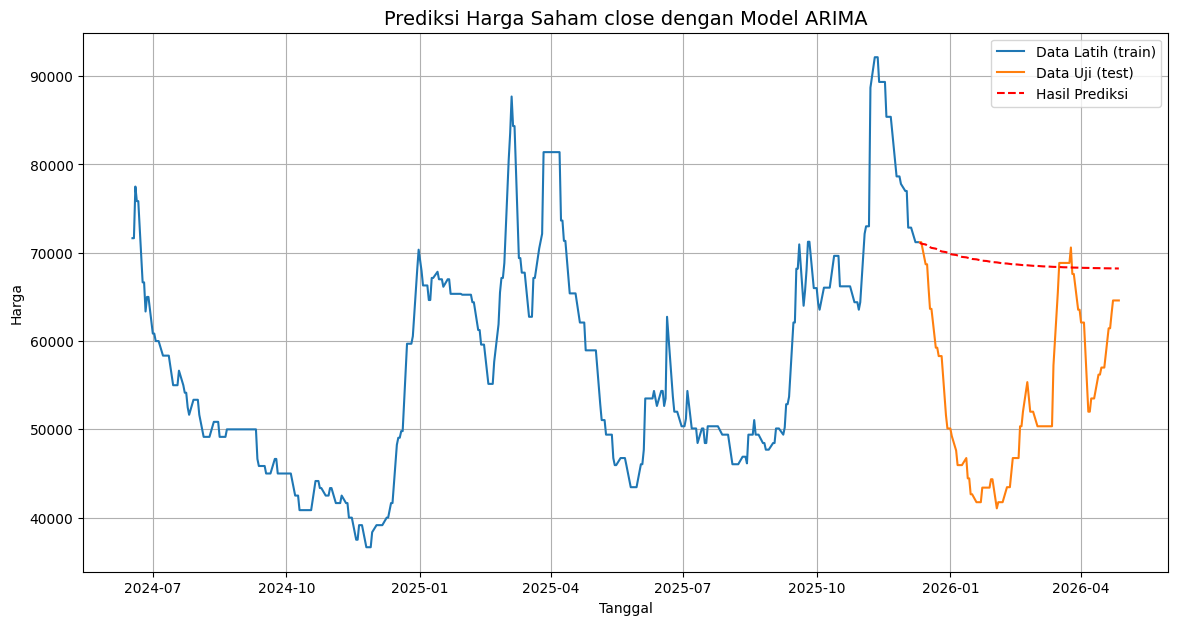

In [30]:
# Visualisasi Model Arima

plt.figure(figsize=(14,7))
plt.plot(train, label='Data Latih (train)')
plt.plot(test, label='Data Uji (test)')
plt.plot(prediction, label='Hasil Prediksi', color='red', linestyle='--')
plt.title('Prediksi Harga Saham close dengan Model ARIMA', fontsize=14)
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.grid(True)
plt.show()